# Convergence for the TRTS 
This is an example of a grid conergence study using a Delft3d case on the Tanana River Test Site (TRTS) located in Nenana, Alaska. In the figure shown bellow is the arial veiw of the test site with the river entering from the bottom of the image and exiting at the top. THe TRTS is used as a test deploment location for Current Energy Converters (CECs). The figure shows an example of a set of transects taken to survey the test site. This particular set of trasects was taken without a CEC in the water, however, a similar patern of trasects would be used if a CEC was operating. This experimental data is used as a comparison for the Delft3D model. Befor comparing to experimental data a grid convergence study is done on the DElft3D modle. The IEC 62600-301 specifies that the grid should be refined so the Grid convergence Idex (GCI) is less than 6% for water level and depth-averaged current speed. The TRTS Delft3D grid used a retagular grid squar grid cells. This example will plot the depth-averaged current speed and water level for the TRTS model with a 8m, 4m, 2m and 1m grid cell edge length.

<img src="data/river/ADCP_transect/transects_w_labels.png" />  

First the Delft3d moduel for MHKiT is imported along with sevreal other python packages. 

In [1]:
import scipy.interpolate as interp
import matplotlib.pyplot as plt
from mhkit.river.io import d3d
import geopandas as gpd
import pandas as pd
import numpy as np
import pygeoops
import netCDF4



# Points for Convergence Comparisons 

### Load River Shape 

Load the shape of the river to calculate the centerline points. The shape of the river was found by doing a bathimetric survey.

In [2]:

# Load the shapefile
combined_geometry = gpd.read_file('combined_geometry.shp')



#### Centerline Points 
Use pygeoops to find the centeline shape. Then the shape is used to find 100 points on the cneterline.

C:\Users\ashly\AppData\Local\Temp\ipykernel_47952\1886639100.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  river  =combined_geometry.geometry.unary_union
C:\Users\ashly\AppData\Local\Temp\ipykernel_47952\1886639100.py:19: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


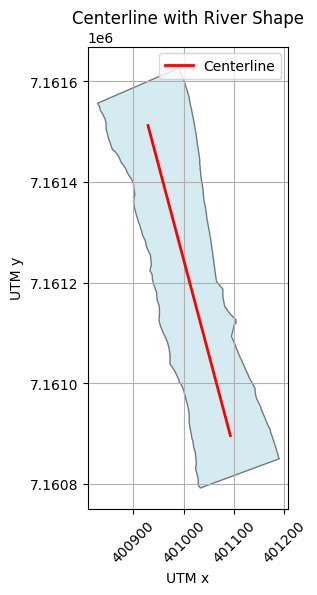

In [3]:
# Calculate the centerline using pygeoops
river  =combined_geometry.geometry.unary_union
centerline_py= pygeoops.centerline(river)


# Plot the combined geometry and centerline
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the shape
combined_geometry.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.5, label='River Shape')

# Plot the centerline
x, y = centerline_py.xy
ax.plot(x, y, color='red', linewidth=2, label='Centerline')

# Add labels and legend
ax.set_xlabel('UTM x')
ax.set_ylabel('UTM y')
ax.legend()
plt.xticks(rotation=45)
plt.title('Centerline with River Shape')
plt.grid(True)
plt.show()

In [4]:
# Get the total length of the centerline
centerline_length = centerline_py.length

# Generate 100 evenly spaced points along the centerline
points_on_centerline = [centerline_py.interpolate(distance) for distance in np.linspace(0, centerline_length, 100)]

# Convert the points to a list of coordinates
points_coordinates = [(point.x, point.y) for point in points_on_centerline]

# Display the first 100 points
# Create a dataframe of points_on_centerline with variables x and y
centerline_points = pd.DataFrame(points_coordinates, columns=['x', 'y'])
centerline_points

,x,y
0,400929.336889,7.161512e+06
1,400930.988201,7.161505e+06
2,400932.639512,7.161499e+06
3,400934.290824,7.161493e+06
4,400935.942135,7.161487e+06
...,...,...
95,401086.211476,7.160921e+06
96,401087.862788,7.160915e+06
97,401089.514099,7.160909e+06
98,401091.165411,7.160902e+06


# Grid Convergence 

The TRTS Delft3D grid used a rectangular grid square grid cells. This example will plot the depth-averaged current speed and water level for the TRTS model with a 8m, 4m, 2m and 1m grid cell edge length.


### Load Delft3d Data

Load the Delft3D model output for all the grid lenghs: 8m, 4m, 2m, and 1m. 


In [5]:
# Load the NetCDF file
dataset_8m_raw = netCDF4.Dataset("data/river/d3d/convergence/grid/FlowFM_map_test.nc") #FlowFM_8m_map.nc # test was run on th HPC cluster
## Test xarray input #dataset_8m_xr = xr.open_dataset('FlowFM_8m_map.nc')
dataset_4m_raw = netCDF4.Dataset('data/river/d3d/convergence/grid/FlowFM_4m_map.nc')
#dataset_2m_raw = netCDF4.Dataset('data/river/d3d/convergence/grid/FlowFM_map_2m.nc')
dataset_1m_raw = netCDF4.Dataset('data/river/d3d/convergence/grid/FlowFM_1m_map.nc')

## Depth Averaged Current Speed

The MHKiT Delft3D (D3D) function `get_all_data_points` is used to import the variable `mesh2d_ucmaga` which is the Flow element center depth-averaged velocity magnitude. The `get_all_data_points` function outputs the coresponding x and y cordinates along with the water depth, water level and time step. The time step defalts to -1 or the last time step in the simulation. The datafram for the 8m grid length resolution is shown.

In [6]:
variable="mesh2d_ucmaga"
dataset_8m =d3d.get_all_data_points(dataset_8m_raw, variable)
dataset_4m =d3d.get_all_data_points(dataset_4m_raw, variable)
#dataset_2m =d3d.get_all_data_points(dataset_2m_raw, variable)
dataset_1m =d3d.get_all_data_points(dataset_1m_raw, variable)
dataset_8m

,x,y,waterdepth,waterlevel,mesh2d_ucmaga,time
index,,,,,,
0,400993.370690,7.160784e+06,0.0,124.536383,0.0,86400.0
1,401000.888231,7.160787e+06,0.0,124.601929,0.0,86400.0
2,400990.634529,7.160792e+06,0.0,124.629313,0.0,86400.0
3,401008.405772,7.160790e+06,0.0,124.557983,0.0,86400.0
4,400998.152070,7.160795e+06,0.0,124.655420,0.0,86400.0
...,...,...,...,...,...,...
105835,401121.611350,7.161648e+06,0.0,122.530091,0.0,86400.0
105836,401111.357648,7.161653e+06,0.0,122.942576,0.0,86400.0
105837,401129.128891,7.161651e+06,0.0,122.544393,0.0,86400.0


### Interpolate Velocity onto Centerline 

Scipy's interp griddata is used to interpolate the velocity data onto the centerline points. A for loop is used to iterate over the 4 grid resolutions. 

In [7]:
grid_resolutions = ['8m' ,'4m']# '1m']# '2m', '1m']
center_line_velocity = {}

for resolution in grid_resolutions:
    dataset = globals()[f'dataset_{resolution}']
    center_line_velocity[resolution] = interp.griddata(
        dataset[["x", "y"]],
        dataset[variable],
        centerline_points[["x", "y"]]
    )



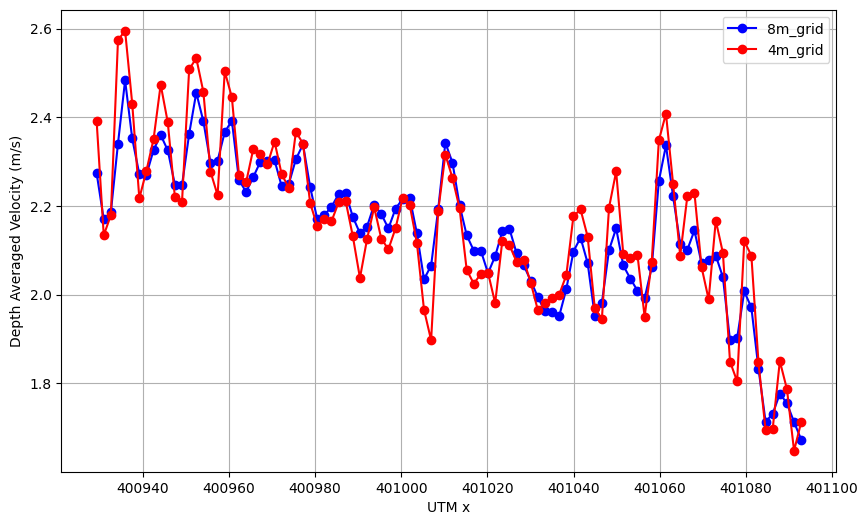

In [13]:
# Plot Depth Averaged Velocity over Centerline
plt.figure(figsize=(10, 6))
plt.plot(centerline_points.x, center_line_velocity['8m'], marker='o', linestyle='-', color='b',label="8m_grid")
plt.plot(centerline_points.x, center_line_velocity['4m'], marker='o', linestyle='-', color='r',label="4m_grid")
#plt.plot(centerline_points.x, center_line_velocity['2m'], marker='o', linestyle='-', color='g',label="2m_grid")
#plt.plot(centerline_points.x, center_line_velocity['1m'], marker='o', linestyle='-', color='m',label="1m_grid")
plt.xlabel('UTM x')
plt.ylabel('Depth Averaged Velocity (m/s)')
plt.grid(True)
plt.legend()
plt.show()

## Waterlevel

The waterlevel data was already obtrained from the depth averaged velocity dataframe. The same for loop process is used to interpolate all 4 grid sizes onto the centerline poins.The results are then ploted. 

In [9]:
grid_resolutions = ['8m', '4m', '1m']# '2m', '1m']
center_line_waterlevel = {}

for resolution in grid_resolutions:
    dataset = globals()[f'dataset_{resolution}']
    center_line_waterlevel[resolution] = interp.griddata(
        dataset[["x", "y"]],
        dataset["waterlevel"],
        centerline_points[["x", "y"]],
    )

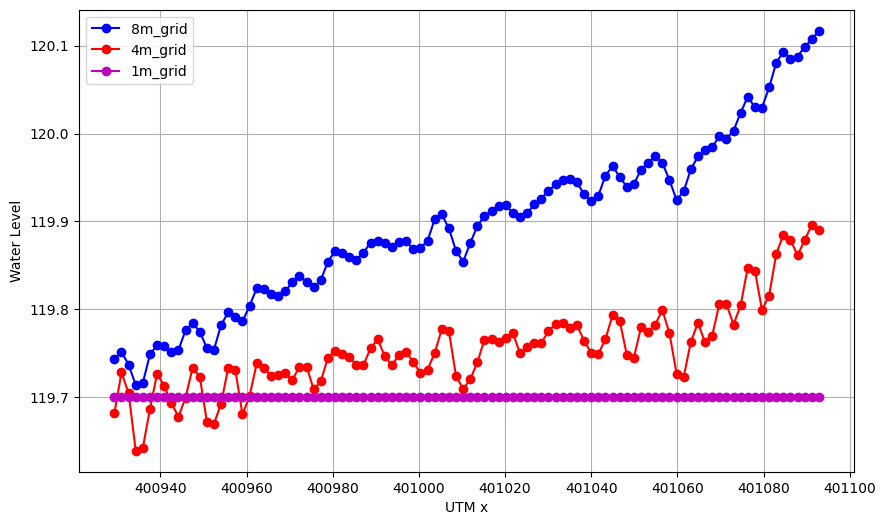

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(centerline_points.x, center_line_waterlevel['8m'], marker='o', linestyle='-', color='b', label="8m_grid")
plt.plot(centerline_points.x, center_line_waterlevel['4m'], marker='o', linestyle='-', color='r', label="4m_grid")
#plt.plot(centerline_points.x, center_line_waterlevel['2m'], marker='o', linestyle='-', color='g', label="2m_grid")
plt.plot(centerline_points.x, center_line_waterlevel['1m'], marker='o', linestyle='-', color='m', label="1m_grid")
plt.xlabel('UTM x')
plt.ylabel('Water Level')
plt.grid(True)
plt.legend()
plt.show()

In [14]:
def calculate_grid_convergence_index(fine_grid, coarse_grid, refinement_ratio,factor_of_safety=1.25, order=2):
    """
    Calculate the Grid Convergence Index (GCI) between two grid sizes. https://www.grc.nasa.gov/WWW/wind/valid/tutorial/spatconv.html

    Parameters
    ----------
    fine_grid: numpy.ndarray
        Results from the finer grid.
    coarse_grid: numpy.ndarray
        Results from the coarser grid.
    refinement_ratio: float 
        Refinement ratio between the grids.
    order: int
        Order of accuracy (default is 2).

    Returns
    -------
    gci: float
        Grid Convergence Index (GCI).
    """
    # Calculate the approximate relative error
    error = np.abs((fine_grid - coarse_grid) / fine_grid)

    # Calculate the GCI
    gci = (factor_of_safety * error) / (refinement_ratio**order - 1)
    return gci

# Example usage
# Assuming `center_line_velocity` contains velocity data for different grid resolutions
grid_resolutions = ['8m', '4m']#1m']# '2m', '1m']
refinement_ratios = [2, 2, 2]  # Refinement ratio between consecutive grids

gci_velocity_results = {}
for i in range(len(grid_resolutions) - 1):
    fine = center_line_velocity[grid_resolutions[i + 1]]
    coarse = center_line_velocity[grid_resolutions[i]]
    refinement_ratio = refinement_ratios[i]
    gci_velocity_results[f"{grid_resolutions[i]}-{grid_resolutions[i + 1]}"] = calculate_grid_convergence_index(
        fine, coarse, refinement_ratio
    )

gci_water_level_results = {}
for i in range(len(grid_resolutions) - 1):
    fine = center_line_waterlevel[grid_resolutions[i + 1]]
    coarse = center_line_waterlevel[grid_resolutions[i]]
    refinement_ratio = refinement_ratios[i]
    gci_water_level_results[f"{grid_resolutions[i]}-{grid_resolutions[i + 1]}"] = calculate_grid_convergence_index(
        fine, coarse, refinement_ratio
    )

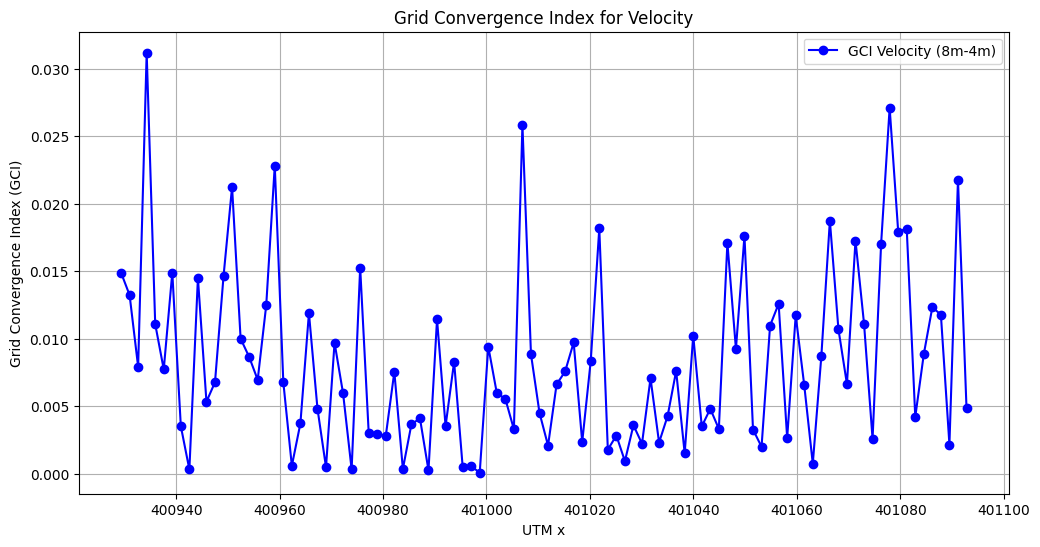

In [ ]:
# Plot GCI results for velocity and water level
plt.figure(figsize=(12, 6))

# Plot GCI for velocity
plt.plot(centerline_points.x, gci_velocity_results['8m-4m'], marker='o', linestyle='-', color='b', label='GCI Velocity (8m-4m)')
#plt.plot(centerline_points.x, gci_velocity_results['4m-2m'], marker='o', linestyle='-', color='r', label='GCI Velocity (4m-2m)')
#plt.plot(centerline_points.x, gci_velocity_results['2m-1m'], marker='o', linestyle='-', color='g', label='GCI Velocity (2m-1m)')


# Add labels, legend, and grid
plt.xlabel('UTM x')
plt.ylabel('Grid Convergence Index (GCI)')
plt.title('Grid Convergence Index for Velocity')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

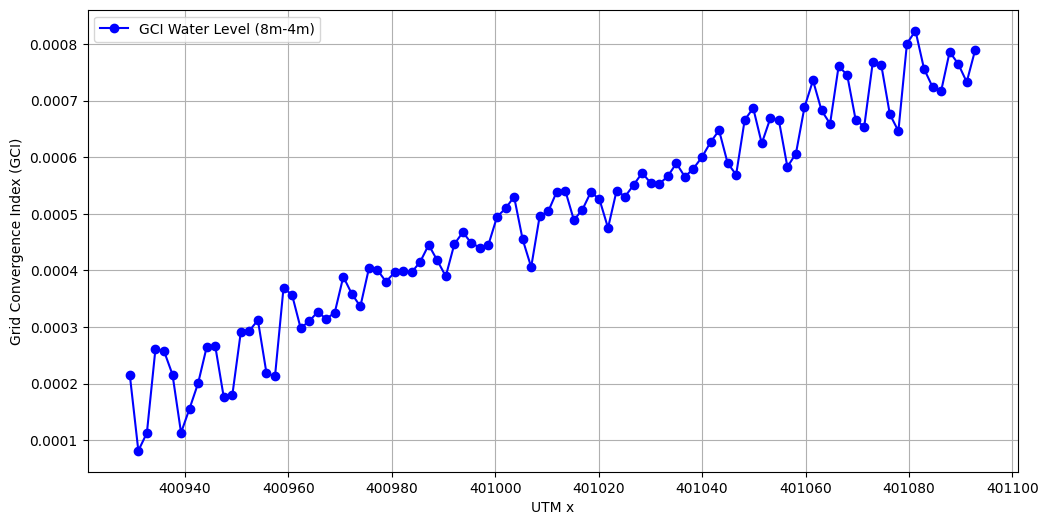

In [15]:
# Plot GCI results for velocity and water level
plt.figure(figsize=(12, 6))


# Plot GCI for water level
plt.plot(centerline_points.x, gci_water_level_results['8m-4m'], marker='o', linestyle='-', color='b', label='GCI Water Level (8m-4m)')

# Add labels, legend, and grid
plt.xlabel('UTM x')
plt.ylabel('Grid Convergence Index (GCI)')
#plt.title('Grid Convergence Index for Water Level')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

# Layer Convergence
This Delft3D grid utalizes sigma layers that mantian a constant number of layers through the variable depths of the river [D3D tecnicl refence manual]. This convergence study will ensure that the water level and depth averaged velocity have a GCI less than 6%. THe number of layers tested are 5, 10, 15, and 20. 

## Imort Data

In [ ]:
# Load the NetCDF file
dataset_20layers_raw = netCDF4.Dataset("data/river/d3d/convergence/layers/FlowFM_20layers_map.nc")
dataset_15layers_raw = netCDF4.Dataset('data/river/d3d/convergence/layers/FlowFM_15layers_map.nc')
dataset_10layers_raw = netCDF4.Dataset('data/river/d3d/convergence/layers/FlowFM_10layers_map.nc')
dataset_5layers_raw = netCDF4.Dataset('data/river/d3d/convergence/layers/FlowFM_5layers_map.nc')

In [ ]:
variable="mesh2d_ucmaga"
dataset_20layers =d3d.get_all_data_points(dataset_20layers_raw, variable)
dataset_15layers =d3d.get_all_data_points(dataset_15layers_raw, variable)
dataset_10layers =d3d.get_all_data_points(dataset_10layers_raw, variable)
dataset_5layers =d3d.get_all_data_points(dataset_5layers_raw, variable)


In [ ]:
layer_resolutions = ['20layers' ,'15layers', '10layers', '5layers']
center_line_velocity = {}

for resolution in layer_resolutions:
    dataset = globals()[f'dataset_{resolution}']
    center_line_velocity[resolution] = interp.griddata(
        dataset[["x", "y"]],
        dataset[variable],
        centerline_points[["x", "y"]]
    )



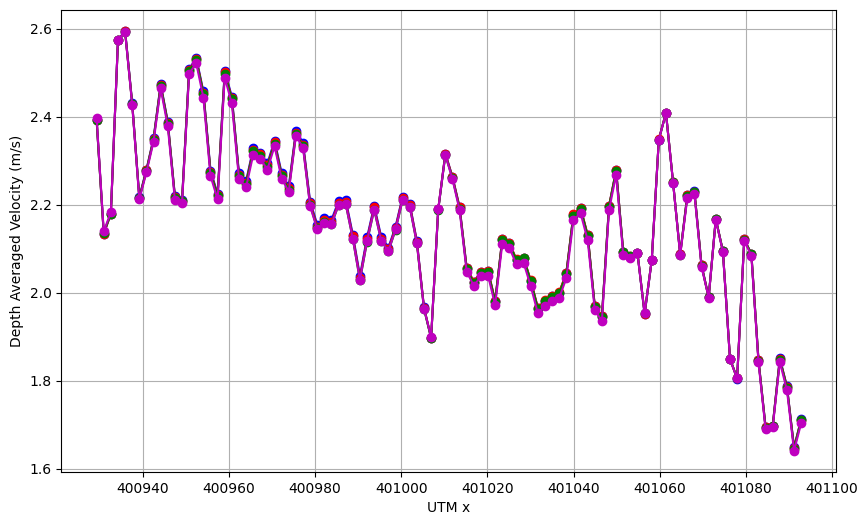

<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

In [ ]:
# Plot Depth Averaged Velocity over Centerline
plt.figure(figsize=(10, 6))
plt.plot(centerline_points.x, center_line_velocity['20layers'], marker='o', linestyle='-', color='b',label="20 layers")
plt.plot(centerline_points.x, center_line_velocity['15layers'], marker='o', linestyle='-', color='r',label="15 layers")
plt.plot(centerline_points.x, center_line_velocity['10layers'], marker='o', linestyle='-', color='g',label="10 layers")
plt.plot(centerline_points.x, center_line_velocity['5layers'], marker='o', linestyle='-', color='m',label="5 layers")
plt.xlabel('UTM x')
plt.ylabel('Depth Averaged Velocity (m/s)')
plt.grid(True)
plt.show()
plt.legend

In [ ]:
grid_resolutions = ['20layers', '15layers', '10layers', '5layers']
center_line_waterlevel = {}

for resolution in grid_resolutions:
    dataset = globals()[f'dataset_{resolution}']
    center_line_waterlevel[resolution] = interp.griddata(
        dataset[["x", "y"]],
        dataset["waterlevel"],
        centerline_points[["x", "y"]],
    )

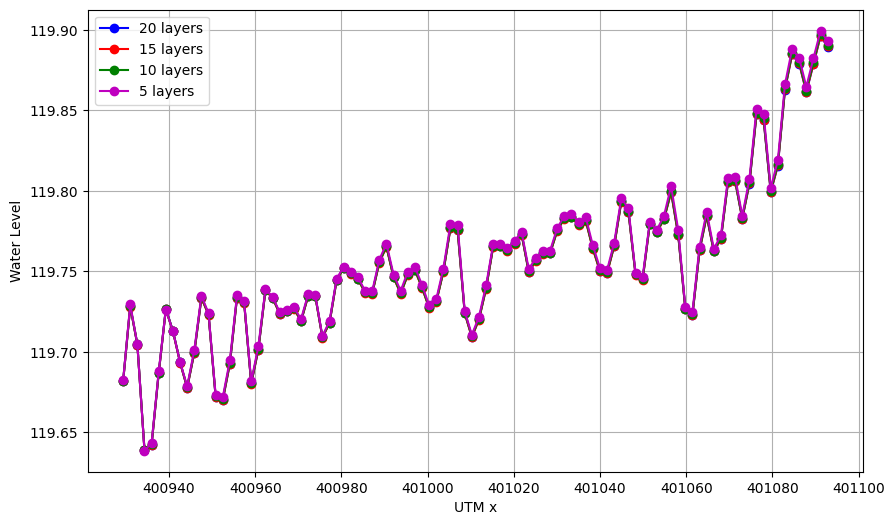

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(centerline_points.x, center_line_waterlevel['20layers'], marker='o', linestyle='-', color='b', label="20 layers")
plt.plot(centerline_points.x, center_line_waterlevel['15layers'], marker='o', linestyle='-', color='r', label="15 layers")
plt.plot(centerline_points.x, center_line_waterlevel['10layers'], marker='o', linestyle='-', color='g', label="10 layers")
plt.plot(centerline_points.x, center_line_waterlevel['5layers'], marker='o', linestyle='-', color='m', label="5 layers")
plt.xlabel('UTM x')
plt.ylabel('Water Level')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Example usage
# Assuming `center_line_velocity` contains velocity data for different grid resolutions
grid_resolutions = ['20layers', '15layers', '10layers', '5layers']
refinement_ratios = [2, 2, 2]  # Refinement ratio between consecutive grids

gci_velocity_results = {}
for i in range(len(grid_resolutions) - 1):
    fine = center_line_velocity[grid_resolutions[i + 1]]
    coarse = center_line_velocity[grid_resolutions[i]]
    refinement_ratio = refinement_ratios[i]
    gci_velocity_results[f"{grid_resolutions[i]}-{grid_resolutions[i + 1]}"] = calculate_grid_convergence_index(
        fine, coarse, refinement_ratio
    )

gci_water_level_results = {}
for i in range(len(grid_resolutions) - 1):
    fine = center_line_waterlevel[grid_resolutions[i + 1]]
    coarse = center_line_waterlevel[grid_resolutions[i]]
    refinement_ratio = refinement_ratios[i]
    gci_water_level_results[f"{grid_resolutions[i]}-{grid_resolutions[i + 1]}"] = calculate_grid_convergence_index(
        fine, coarse, refinement_ratio
    )

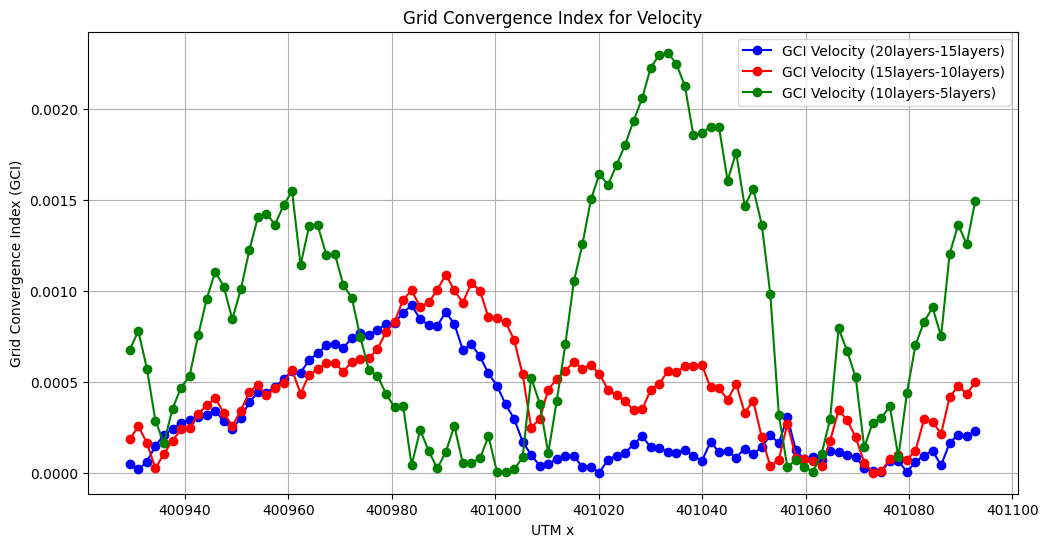

In [ ]:
# Plot GCI results for velocity and water level
plt.figure(figsize=(12, 6))

# Plot GCI for velocity
plt.plot(centerline_points.x, gci_velocity_results['20layers-15layers'], marker='o', linestyle='-', color='b', label='GCI Velocity (20layers-15layers)')
plt.plot(centerline_points.x, gci_velocity_results['15layers-10layers'], marker='o', linestyle='-', color='r', label='GCI Velocity (15layers-10layers)')
plt.plot(centerline_points.x, gci_velocity_results['10layers-5layers'], marker='o', linestyle='-', color='g', label='GCI Velocity (10layers-5layers)')


# Add labels, legend, and grid
plt.xlabel('UTM x')
plt.ylabel('Grid Convergence Index (GCI)')
plt.title('Grid Convergence Index for Velocity')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

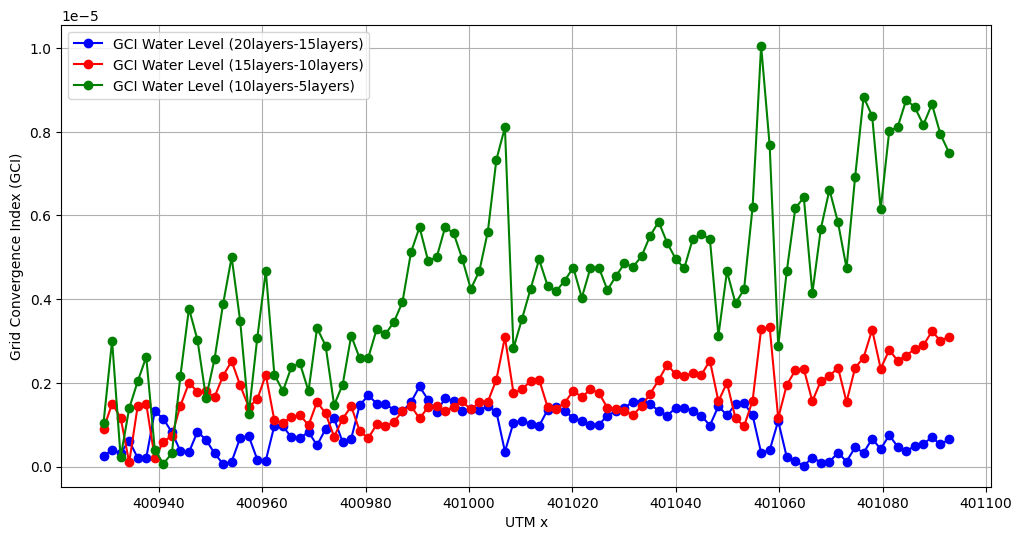

In [ ]:
# Plot GCI results for velocity and water level
plt.figure(figsize=(12, 6))


# Plot GCI for water level
plt.plot(centerline_points.x, gci_water_level_results['20layers-15layers'], marker='o', linestyle='-', color='b', label='GCI Water Level (20layers-15layers)')
plt.plot(centerline_points.x, gci_water_level_results['15layers-10layers'], marker='o', linestyle='-', color='r', label='GCI Water Level (15layers-10layers)')
plt.plot(centerline_points.x, gci_water_level_results['10layers-5layers'], marker='o', linestyle='-', color='g', label='GCI Water Level (10layers-5layers)')

# Add labels, legend, and grid
plt.xlabel('UTM x')
plt.ylabel('Grid Convergence Index (GCI)')
#plt.title('Grid Convergence Index for Water Level')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

# Time Convergence 

The time convergence looks at the Courant-Friedrichs-Lewy number (CFL) to ensure that th model has ran long enough. THe CFL numder is a measure of the time step to grid size. CFL number 0.35, 0.7, 1.4, and 2.8 ar tested for confergence. 

$CFL= \frac{u\Delta t}{\Delta x}$

## Import Data

In [ ]:
# Load the NetCDF file
dataset_CFL_035_raw = netCDF4.Dataset("data/river/d3d/convergence/time/FlowFM_CFL0.35_map.nc")
dataset_CFL_07_raw = netCDF4.Dataset('data/river/d3d/convergence/time/FlowFM_CFL_0.7_map.nc')
dataset_CFL_14_raw = netCDF4.Dataset('data/river/d3d/convergence/time/FlowFM_CFL1.4_map.nc')
dataset_CFL_28_raw = netCDF4.Dataset('data/river/d3d/convergence/time/FlowFM_CFL2.8_map.nc')

## Depth Averaged Velocity 

In [ ]:
variable="mesh2d_ucmaga"
dataset_035time =d3d.get_all_data_points(dataset_CFL_035_raw, variable)
dataset_07time =d3d.get_all_data_points(dataset_CFL_07_raw, variable)
dataset_14time =d3d.get_all_data_points(dataset_CFL_14_raw, variable)
dataset_28time =d3d.get_all_data_points(dataset_CFL_28_raw, variable)

In [ ]:
CFL_resolutions = ['035time' ,'07time', '14time', '28time']
center_line_velocity = {}

for resolution in CFL_resolutions:
    dataset = globals()[f'dataset_{resolution}']
    center_line_velocity[resolution] = interp.griddata(
        dataset[["x", "y"]],
        dataset[variable],
        centerline_points[["x", "y"]]
    )

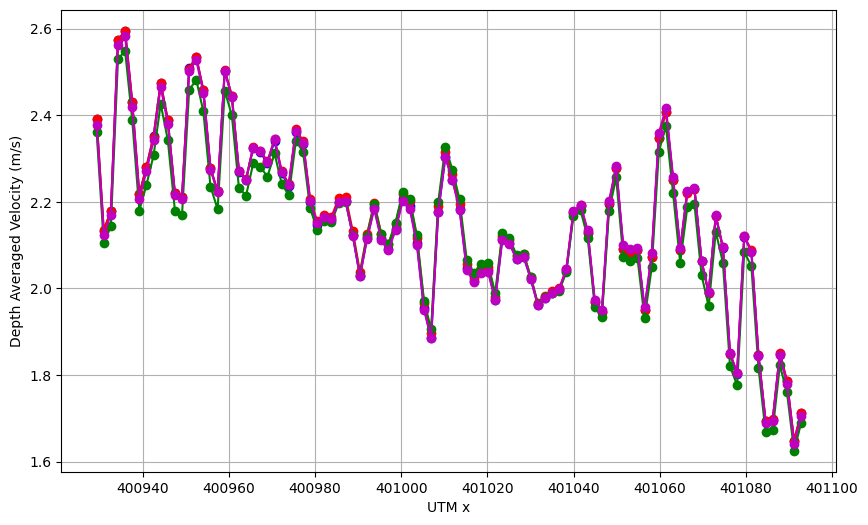

<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

In [ ]:
# Plot Depth Averaged Velocity over Centerline
plt.figure(figsize=(10, 6))
plt.plot(centerline_points.x, center_line_velocity['035time'], marker='o', linestyle='-', color='b',label="0.35 CFL")
plt.plot(centerline_points.x, center_line_velocity['07time'], marker='o', linestyle='-', color='r',label="0.7 CFL")
plt.plot(centerline_points.x, center_line_velocity['14time'], marker='o', linestyle='-', color='g',label="1.4 CFL")
plt.plot(centerline_points.x, center_line_velocity['28time'], marker='o', linestyle='-', color='m',label="2.8 CFL")
plt.xlabel('UTM x')
plt.ylabel('Depth Averaged Velocity (m/s)')
plt.grid(True)
plt.show()
plt.legend

In [ ]:
CFL_resolutions = ['035time' ,'07time', '14time', '28time']
center_line_waterlevel = {}

for resolution in CFL_resolutions:
    dataset = globals()[f'dataset_{resolution}']
    center_line_waterlevel[resolution] = interp.griddata(
        dataset[["x", "y"]],
        dataset["waterlevel"],
        centerline_points[["x", "y"]],
    )

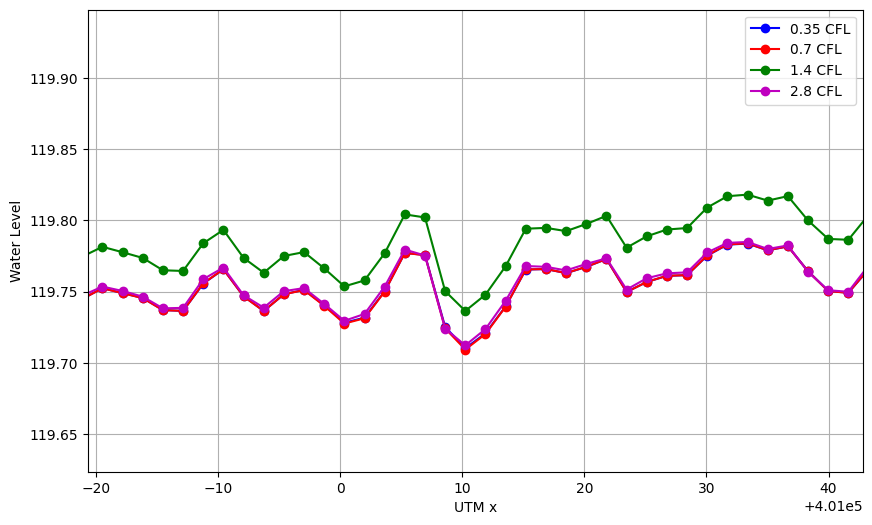

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(centerline_points.x, center_line_waterlevel['035time'], marker='o', linestyle='-', color='b', label="0.35 CFL")
plt.plot(centerline_points.x, center_line_waterlevel['07time'], marker='o', linestyle='-', color='r', label="0.7 CFL")
plt.plot(centerline_points.x, center_line_waterlevel['14time'], marker='o', linestyle='-', color='g', label="1.4 CFL")
plt.plot(centerline_points.x, center_line_waterlevel['28time'], marker='o', linestyle='-', color='m', label="2.8 CFL")
plt.xlabel('UTM x')
plt.ylabel('Water Level')
plt.xlim( centerline_points.x.min()+50, centerline_points.x.max()-50)
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Example usage
# Assuming `center_line_velocity` contains velocity data for different grid resolutions
CFL_resolutions = ['035time' ,'07time', '14time', '28time']
refinement_ratios = [2, 2, 2]  # Refinement ratio between consecutive grids

gci_velocity_results = {}
for i in range(len(CFL_resolutions) - 1):
    fine = center_line_velocity[CFL_resolutions[i + 1]]
    coarse = center_line_velocity[CFL_resolutions[i]]
    refinement_ratio = refinement_ratios[i]
    gci_velocity_results[f"{CFL_resolutions[i]}-{CFL_resolutions[i + 1]}"] = calculate_grid_convergence_index(
        fine, coarse, refinement_ratio
    )

gci_water_level_results = {}
for i in range(len(CFL_resolutions) - 1):
    fine = center_line_waterlevel[CFL_resolutions[i + 1]]
    coarse = center_line_waterlevel[CFL_resolutions[i]]
    refinement_ratio = refinement_ratios[i]
    gci_water_level_results[f"{CFL_resolutions[i]}-{CFL_resolutions[i + 1]}"] = calculate_grid_convergence_index(
        fine, coarse, refinement_ratio
    )

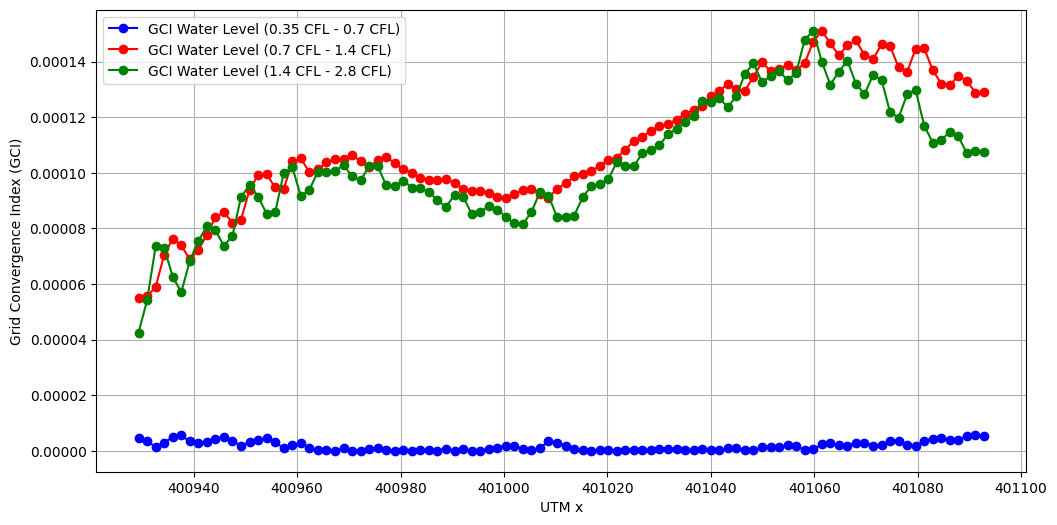

In [ ]:
# Plot GCI results for velocity and water level
plt.figure(figsize=(12, 6))


# Plot GCI for water level
plt.plot(centerline_points.x, gci_water_level_results['035time-07time'], marker='o', linestyle='-', color='b', label='GCI Water Level (0.35 CFL - 0.7 CFL)')
plt.plot(centerline_points.x, gci_water_level_results['07time-14time'], marker='o', linestyle='-', color='r', label='GCI Water Level (0.7 CFL - 1.4 CFL)')
plt.plot(centerline_points.x, gci_water_level_results['14time-28time'], marker='o', linestyle='-', color='g', label='GCI Water Level (1.4 CFL - 2.8 CFL)')

# Add labels, legend, and grid
plt.xlabel('UTM x')
plt.ylabel('Grid Convergence Index (GCI)')
#plt.title('Grid Convergence Index for Water Level')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()